## Question 6: Principal Component Analysis (PCA)

### Part 1: Extract Gene Expression Data

We'll extract XBP1 and GATA3 expression levels from all patient samples and visualize their relationship, colored by ER status (ER+ vs ER- breast cancer).

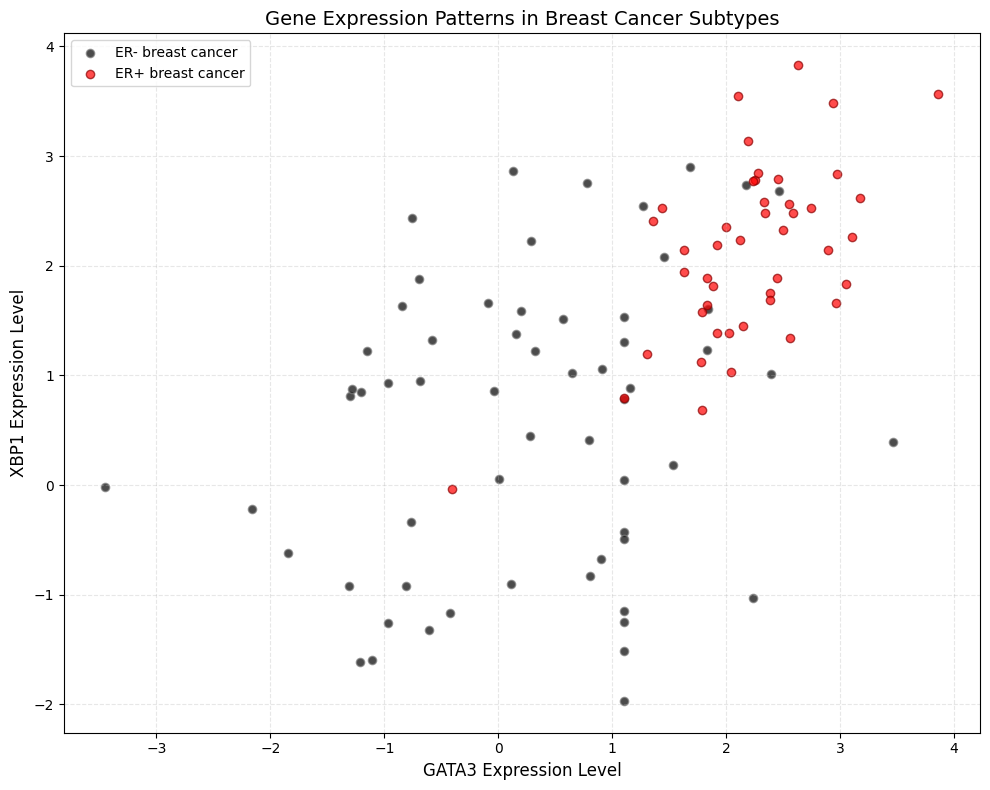

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def load_gene_expression_data():
    expression_data = pd.read_csv("data/filtered.tsv", sep="\t")
    
    class_data = pd.read_csv("data/class.tsv", sep="\t", header=None)
    class_labels = class_data[0].values
    
    gene_mappings = pd.read_csv("data/columns.tsv", sep="\t", comment="#")
    
    return expression_data, gene_mappings, class_labels

expression_data, gene_mappings, class_labels = load_gene_expression_data()

gata3_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'GATA3', 'ID'].values[0])
xbp1_id = str(gene_mappings.loc[gene_mappings['GeneSymbol'] == 'XBP1', 'ID'].values[0])

gata3_col = f" {gata3_id}" if f" {gata3_id}" in expression_data.columns else gata3_id
xbp1_col = f" {xbp1_id}" if f" {xbp1_id}" in expression_data.columns else xbp1_id

gata3_expression = expression_data[gata3_col].values
xbp1_expression = expression_data[xbp1_col].values

er_negative_mask = (class_labels == 0)
er_positive_mask = (class_labels == 1)

plt.figure(figsize=(10, 8))

plt.scatter(gata3_expression[er_negative_mask], 
            xbp1_expression[er_negative_mask],
            color='black', 
            alpha=0.7, 
            label='ER- breast cancer',
            edgecolor='gray')

plt.scatter(gata3_expression[er_positive_mask], 
            xbp1_expression[er_positive_mask],
            color='red', 
            alpha=0.7, 
            label='ER+ breast cancer',
            edgecolor='darkred')

plt.xlabel('GATA3 Expression Level', fontsize=12)
plt.ylabel('XBP1 Expression Level', fontsize=12)
plt.title('Gene Expression Patterns in Breast Cancer Subtypes', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Part 2: Manual PCA Implementation

We'll implement PCA from scratch to understand the underlying mathematics and project the data onto the principal components.

#### PCA Algorithm Steps:

1. **Data Preparation**
   - Center the data by subtracting the mean of each feature

2. **Covariance Matrix Calculation**
   - Compute the covariance matrix to understand feature relationships

3. **Eigenvalue Decomposition**
   - Find eigenvectors and eigenvalues of the covariance matrix
   - Eigenvectors represent the principal components' directions
   - Eigenvalues represent the variance along each component

4. **Principal Component Selection**
   - Sort eigenvectors by decreasing eigenvalues
   - Select top components that explain most variance

5. **Data Projection**
   - Project original data onto principal components

Explained variance ratio:
PC1: 0.7792 (77.9%)
PC2: 0.2208 (22.1%)


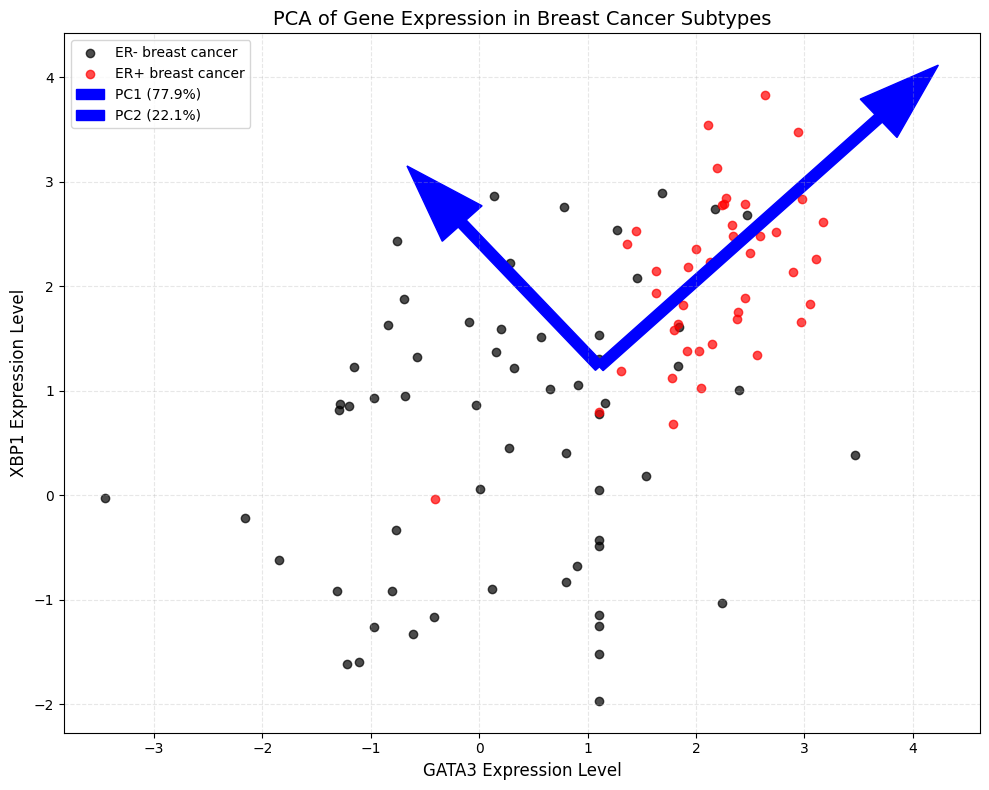

In [3]:
def implement_pca(data, class_labels):
    data_mean = np.mean(data, axis=0)
    centered_data = data - data_mean
    
    cov_matrix = np.cov(centered_data, rowvar=False)
    
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    projected_data = np.dot(centered_data, eigenvectors)
    
    return eigenvectors, eigenvalues, projected_data

expression_matrix = np.column_stack((gata3_expression, xbp1_expression))

principal_components, explained_variance, projected_data = implement_pca(expression_matrix, class_labels)

total_variance = np.sum(explained_variance)
explained_ratio = explained_variance / total_variance
print("Explained variance ratio:")
for i, ratio in enumerate(explained_ratio):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%)")

plt.figure(figsize=(10, 8))

plt.scatter(expression_matrix[er_negative_mask, 0], expression_matrix[er_negative_mask, 1], 
            color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(expression_matrix[er_positive_mask, 0], expression_matrix[er_positive_mask, 1], 
            color='red', alpha=0.7, label='ER+ breast cancer')

origin = np.mean(expression_matrix, axis=0)
for i in range(2):
    pc_vector = principal_components[:, i] * np.sqrt(explained_variance[i]) * 2
    plt.arrow(origin[0], origin[1], pc_vector[0], pc_vector[1], 
              color='blue', width=0.1, head_width=0.5, 
              label=f"PC{i+1} ({explained_ratio[i]:.1%})")

plt.xlabel('GATA3 Expression Level', fontsize=12)
plt.ylabel('XBP1 Expression Level', fontsize=12)
plt.title('PCA of Gene Expression in Breast Cancer Subtypes', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Part 3: Projection onto PC1 (Stripplot Visualization)

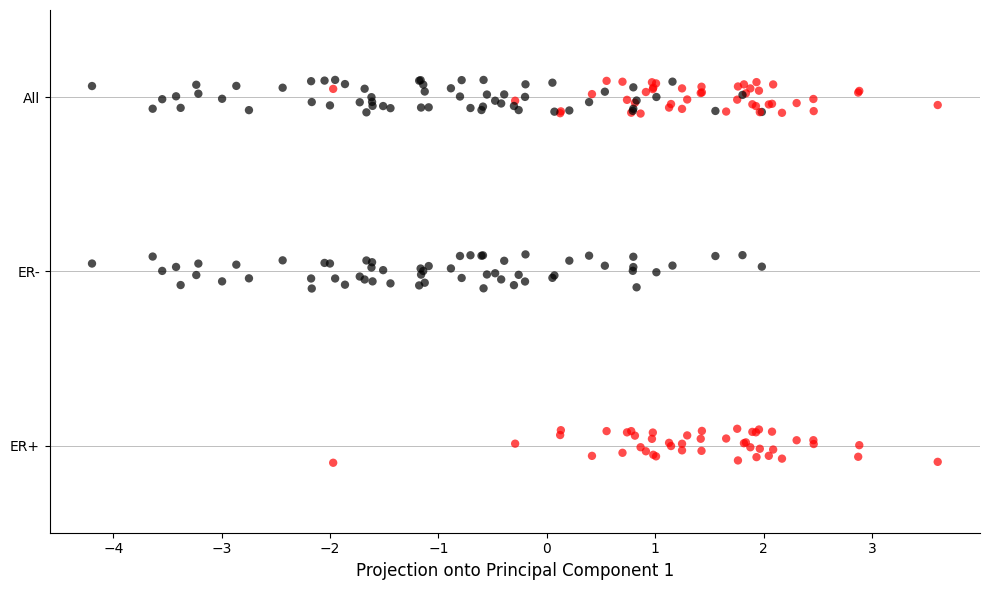

In [4]:
def create_pc1_projection_plot(projected_data, class_labels):
    pc1_values = projected_data[:, 0]
    
    plot_data = pd.DataFrame({
        'PC1': pc1_values,
        'Group': ['All'] * len(pc1_values),
        'ER_Status': ['ER-' if label == 0 else 'ER+' for label in class_labels],
        'Color': ['black' if label == 0 else 'red' for label in class_labels]
    })
    
    er_negative_data = pd.DataFrame({
        'PC1': pc1_values[class_labels == 0],
        'Group': ['ER-'] * np.sum(class_labels == 0),
        'ER_Status': ['ER-'] * np.sum(class_labels == 0),
        'Color': ['black'] * np.sum(class_labels == 0)
    })
    
    er_positive_data = pd.DataFrame({
        'PC1': pc1_values[class_labels == 1],
        'Group': ['ER+'] * np.sum(class_labels == 1),
        'ER_Status': ['ER+'] * np.sum(class_labels == 1),
        'Color': ['red'] * np.sum(class_labels == 1)
    })
    
    combined_data = pd.concat([plot_data, er_negative_data, er_positive_data], ignore_index=True)
    
    plt.figure(figsize=(10, 6))
    ax = sns.stripplot(data=combined_data, x='PC1', y='Group', 
                       hue='Color', palette={'black': 'black', 'red': 'red'},
                       jitter=True, alpha=0.7, size=6)
    
    ax.yaxis.grid(True, linestyle='-', color='gray', linewidth=0.5, alpha=0.7) 
    
    plt.legend([],[], frameon=False)
    plt.xlabel('Projection onto Principal Component 1', fontsize=12)
    plt.ylabel('')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

create_pc1_projection_plot(projected_data, class_labels)